<a href="https://colab.research.google.com/github/PittuSaiPrathvik/xyz/blob/main/Data_Science_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported.")

Libraries imported.


In [4]:
import pandas as pd
import io
import zipfile
from urllib.request import urlopen

# Official UCI zip archive URL
uci_zip_url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"

# Download the main archive
response = urlopen(uci_zip_url)
zip_bytes = io.BytesIO(response.read())

with zipfile.ZipFile(zip_bytes) as outer_zip:
    # Extract the nested 'student.zip' archive
    inner_zip_bytes = io.BytesIO(outer_zip.read("student.zip"))

    with zipfile.ZipFile(inner_zip_bytes) as inner_zip:
        # Load the CSV files from inside student.zip
        math_df = pd.read_csv(inner_zip.open("student-mat.csv"), sep=";")
        portuguese_df = pd.read_csv(inner_zip.open("student-por.csv"), sep=";")

# Add subject identifiers
math_df["subject"] = "Mathematics"
portuguese_df["subject"] = "Portuguese"

# Combine datasets
df = pd.concat([math_df, portuguese_df], ignore_index=True)

print("Combined DataFrame shape:", df.shape)

Combined DataFrame shape: (1044, 34)


In [5]:
df["performance"] = np.where(
    df["G3"] >= 10,
    "Pass",
    "Fail"
)

print(
    df["performance"].value_counts()
)

performance
Pass    814
Fail    230
Name: count, dtype: int64


In [6]:
total_records = len(df)

total_features = len(
    df.columns
)

average_grade = df["G3"].mean()

median_grade = df["G3"].median()

average_absences = df["absences"].mean()

pass_rate = (
    df["performance"] == "Pass"
).mean() * 100

print("Total records:", total_records)
print("Total columns:", total_features)
print("Average final grade:", round(average_grade, 2))
print("Median final grade:", median_grade)
print(
    "Average absences:",
    round(average_absences, 2)
)
print(
    "Pass rate:",
    round(pass_rate, 2),
    "%"
)

Total records: 1044
Total columns: 35
Average final grade: 11.34
Median final grade: 11.0
Average absences: 4.43
Pass rate: 77.97 %


In [7]:
executive_summary = pd.DataFrame({

    "Metric": [
        "Total Records",
        "Total Features",
        "Average Final Grade",
        "Median Final Grade",
        "Average Absences",
        "Pass Rate"
    ],

    "Value": [
        total_records,
        total_features,
        round(average_grade, 2),
        median_grade,
        round(average_absences, 2),
        round(pass_rate, 2)
    ]
})

executive_summary

,Metric,Value
0,Total Records,1044.00
1,Total Features,35.00
2,Average Final Grade,11.34
3,Median Final Grade,11.00
4,Average Absences,4.43
5,Pass Rate,77.97


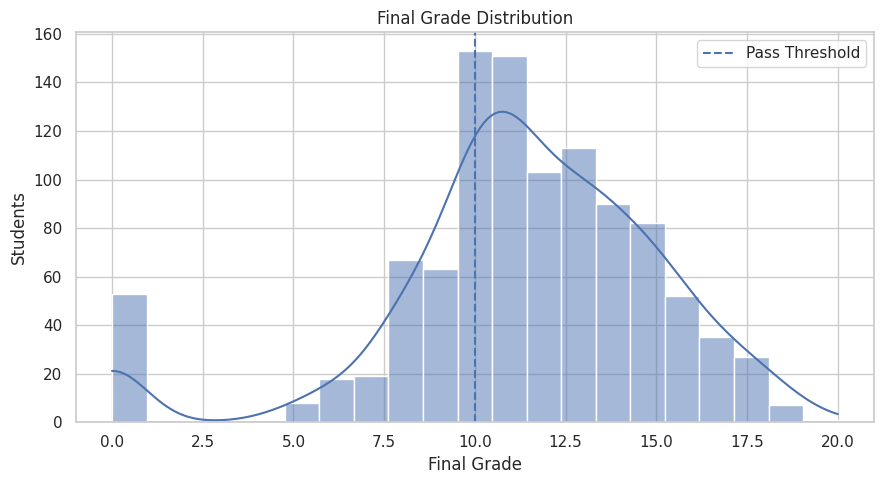

In [8]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="G3",
    bins=21,
    kde=True
)

plt.axvline(
    10,
    linestyle="--",
    label="Pass Threshold"
)

plt.title(
    "Final Grade Distribution"
)

plt.xlabel("Final Grade")
plt.ylabel("Students")

plt.legend()

plt.tight_layout()

plt.savefig(
    "week4_grade_distribution.png",
    dpi=300
)

plt.show()

In [9]:
studytime_summary = (
    df.groupby("studytime")["G3"]
    .agg(
        ["mean", "median", "count"]
    )
    .round(2)
)

studytime_summary

,mean,median,count
studytime,,,
1,10.58,11.0,317
2,11.34,11.0,503
3,12.49,13.0,162
4,12.27,12.0,62


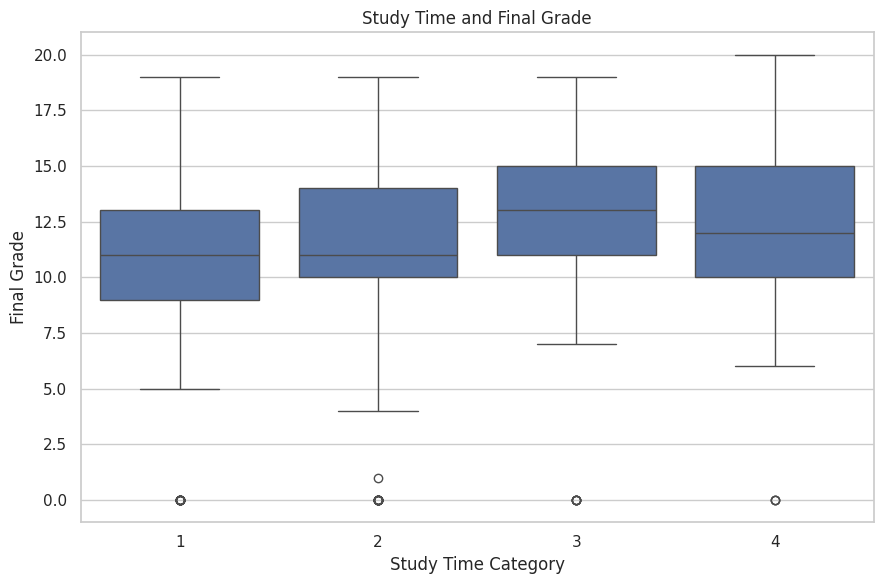

In [10]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="studytime",
    y="G3"
)

plt.title(
    "Study Time and Final Grade"
)

plt.xlabel("Study Time Category")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week4_studytime.png",
    dpi=300
)

plt.show()

In [11]:
failure_summary = (
    df.groupby("failures")["G3"]
    .agg(
        ["mean", "median", "count"]
    )
    .round(2)
)

failure_summary

,mean,median,count
failures,,,
0,12.05,12.0,861
1,8.43,10.0,120
2,7.48,8.0,33
3,6.80,8.0,30


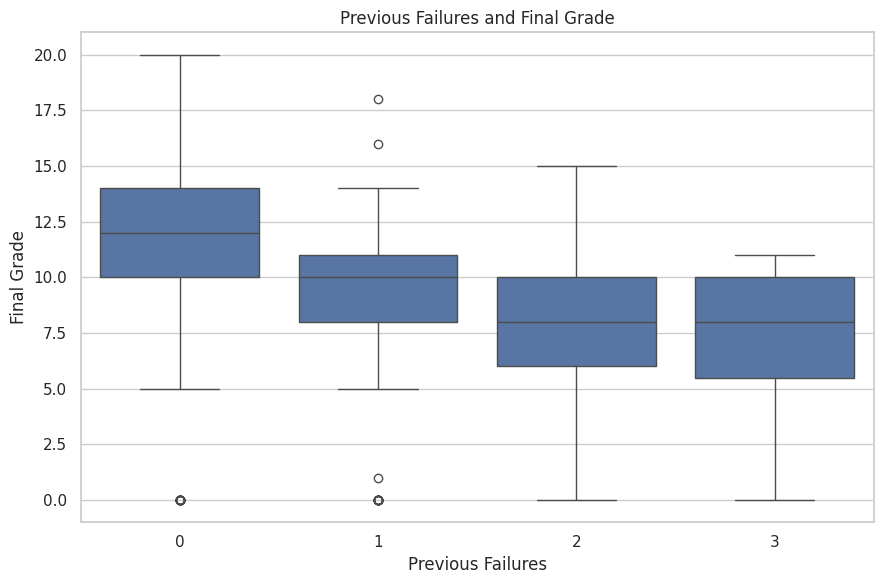

In [12]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="failures",
    y="G3"
)

plt.title(
    "Previous Failures and Final Grade"
)

plt.xlabel("Previous Failures")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week4_failures.png",
    dpi=300
)

plt.show()

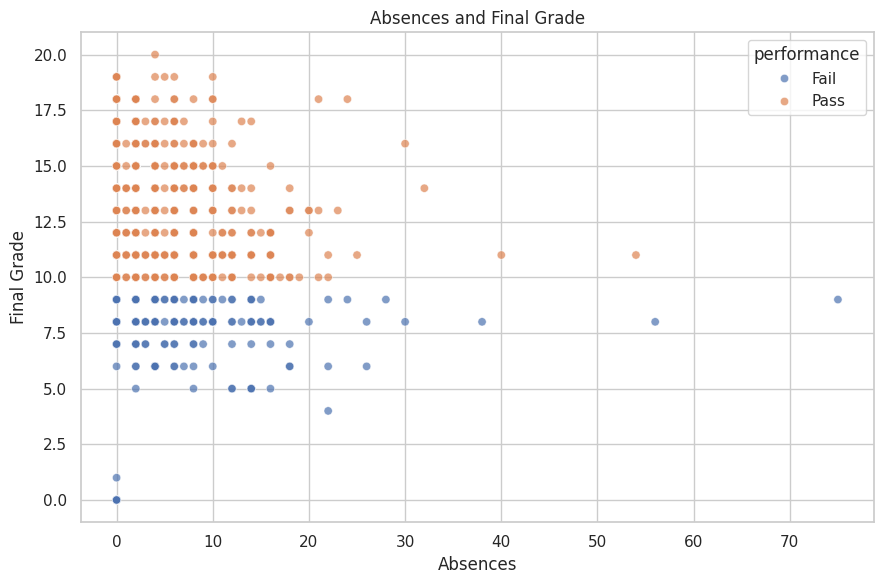

In [13]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="absences",
    y="G3",
    hue="performance",
    alpha=0.7
)

plt.title(
    "Absences and Final Grade"
)

plt.xlabel("Absences")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week4_absences.png",
    dpi=300
)

plt.show()

In [14]:
subject_summary = (
    df.groupby("subject")["G3"]
    .agg(
        ["mean", "median", "count"]
    )
    .round(2)
)

subject_summary

,mean,median,count
subject,,,
Mathematics,10.42,11.0,395
Portuguese,11.91,12.0,649


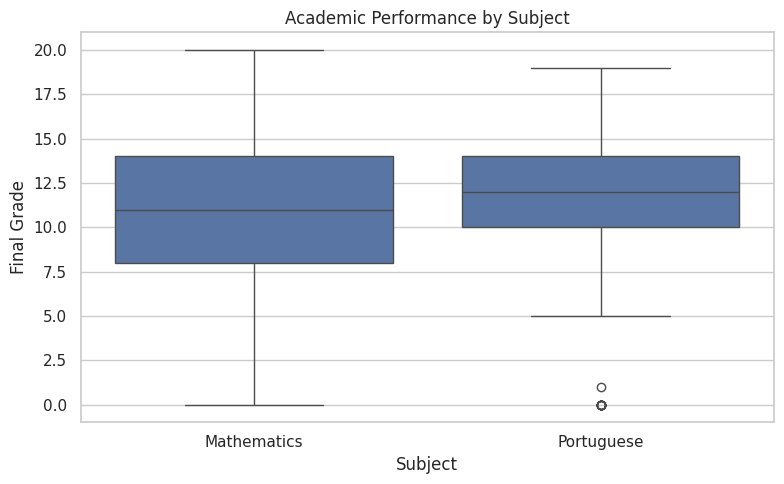

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="subject",
    y="G3"
)

plt.title(
    "Academic Performance by Subject"
)

plt.xlabel("Subject")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week4_subject_comparison.png",
    dpi=300
)

plt.show()

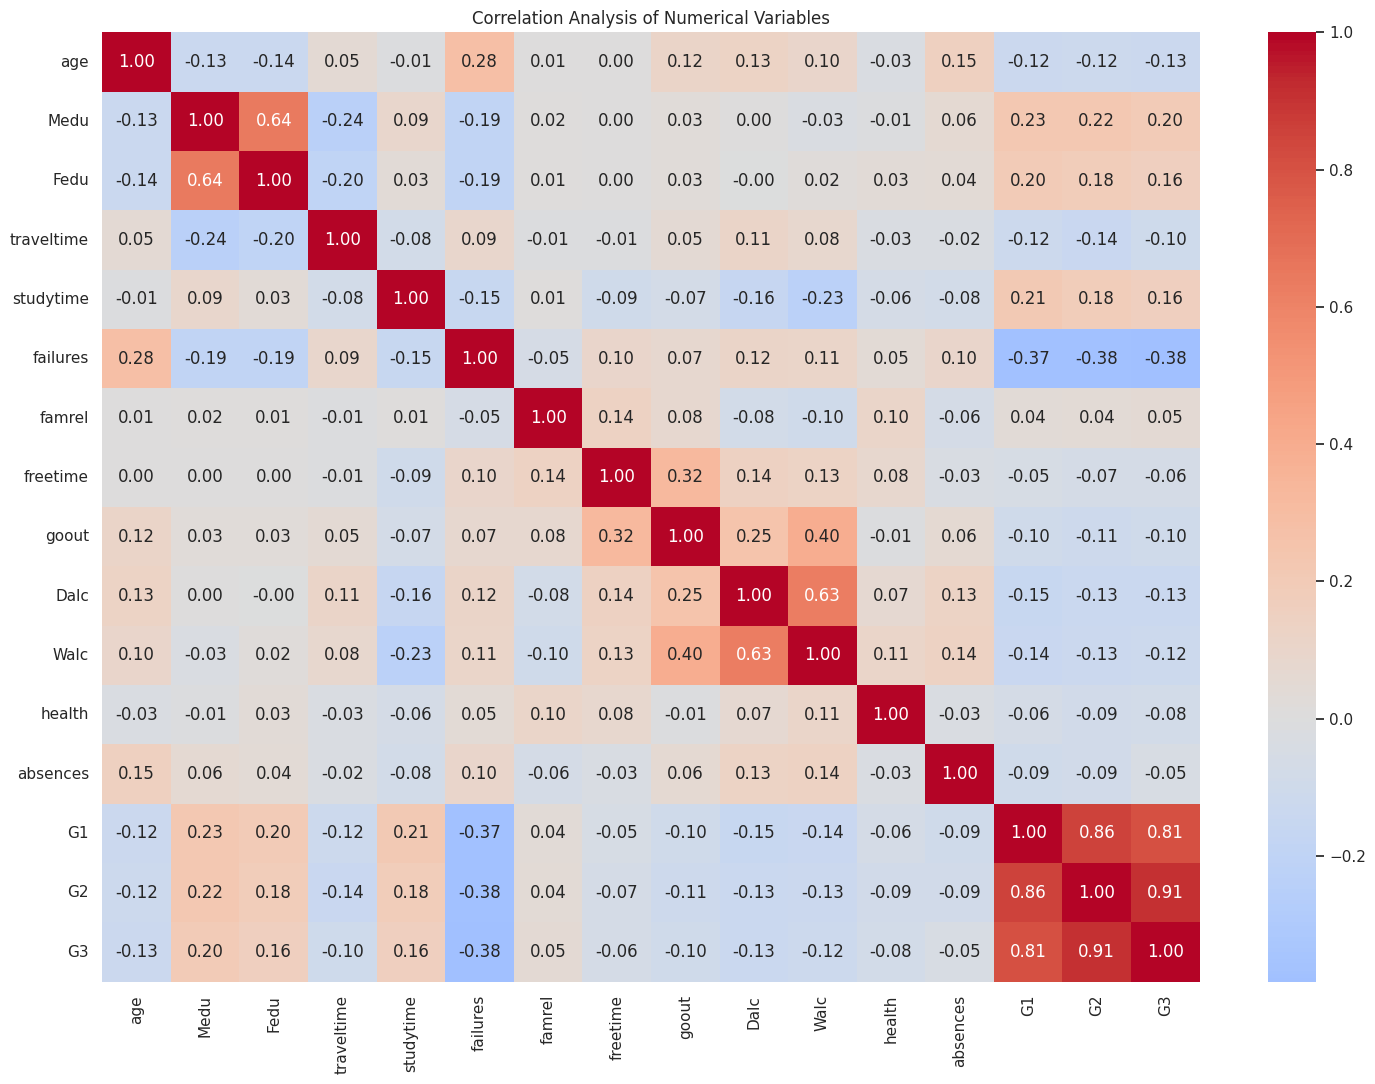

In [16]:
numeric_df = df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr()

plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Analysis of Numerical Variables"
)

plt.tight_layout()

plt.savefig(
    "week4_correlation.png",
    dpi=300
)

plt.show()

In [17]:
columns_to_remove = [
    "G1",
    "G2",
    "G3",
    "performance"
]

X = df.drop(
    columns=columns_to_remove
)

y = df["performance"]

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            __import__(
                "sklearn.impute",
                fromlist=["SimpleImputer"]
            ).SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            __import__(
                "sklearn.impute",
                fromlist=["SimpleImputer"]
            ).SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

final_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                random_state=42
            )
        )
    ]
)

final_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'Medu', 'Fedu',
                                                   'traveltime', 'studytime',
                                                   'failures', 'famrel',
                                                   'freetime', 'goout', 'Dalc',
                                                   'Walc', 'health',
                                                   'absences']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['school', 'sex', 'address',
                                                   'famsize', 'Pstatus', 'Mjob',
                                                   'Fjob', 'reason', 'guardian',
                                                   'schoolsup', 'famsup',
                                                   'paid', 'activities',
                                                   'nursery', 'higher',
                                                   'internet', 'romantic',
                                                   'subject'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=300,
                                        random_state=42))])

In [20]:
predictions = final_model.predict(
    X_test
)

probabilities = final_model.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        predictions
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        (y_test == "Pass").astype(int),
        probabilities
    )
)

              precision    recall  f1-score   support

        Fail       0.62      0.22      0.32        46
        Pass       0.81      0.96      0.88       163

    accuracy                           0.80       209
   macro avg       0.72      0.59      0.60       209
weighted avg       0.77      0.80      0.76       209

ROC-AUC: 0.7570018671645773


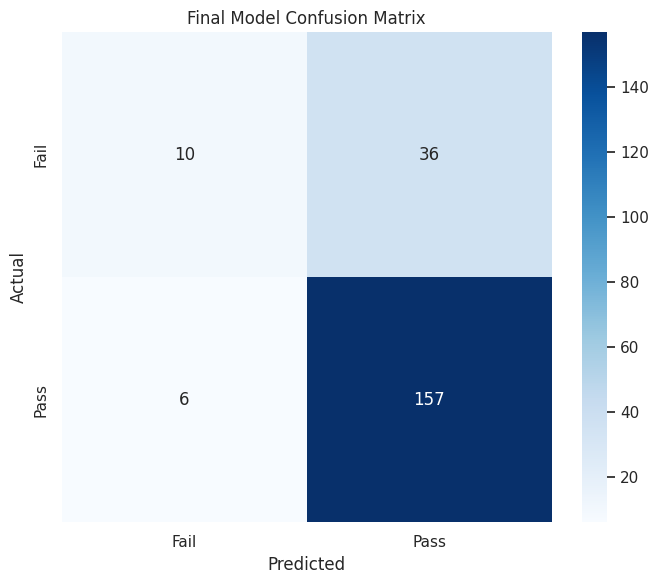

In [21]:
cm = confusion_matrix(
    y_test,
    predictions,
    labels=["Fail", "Pass"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title(
    "Final Model Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "week4_confusion_matrix.png",
    dpi=300
)

plt.show()

In [22]:
feature_names = (
    final_model
    .named_steps[
        "preprocessing"
    ]
    .get_feature_names_out()
)

importances = (
    final_model
    .named_steps[
        "model"
    ]
    .feature_importances_
)

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importances

}).sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
5,numeric__failures,0.108241
12,numeric__absences,0.067626
8,numeric__goout,0.034185
56,categorical__subject_Mathematics,0.034099
0,numeric__age,0.032332
7,numeric__freetime,0.031553
57,categorical__subject_Portuguese,0.030527
10,numeric__Walc,0.029841
6,numeric__famrel,0.027453
1,numeric__Medu,0.027390


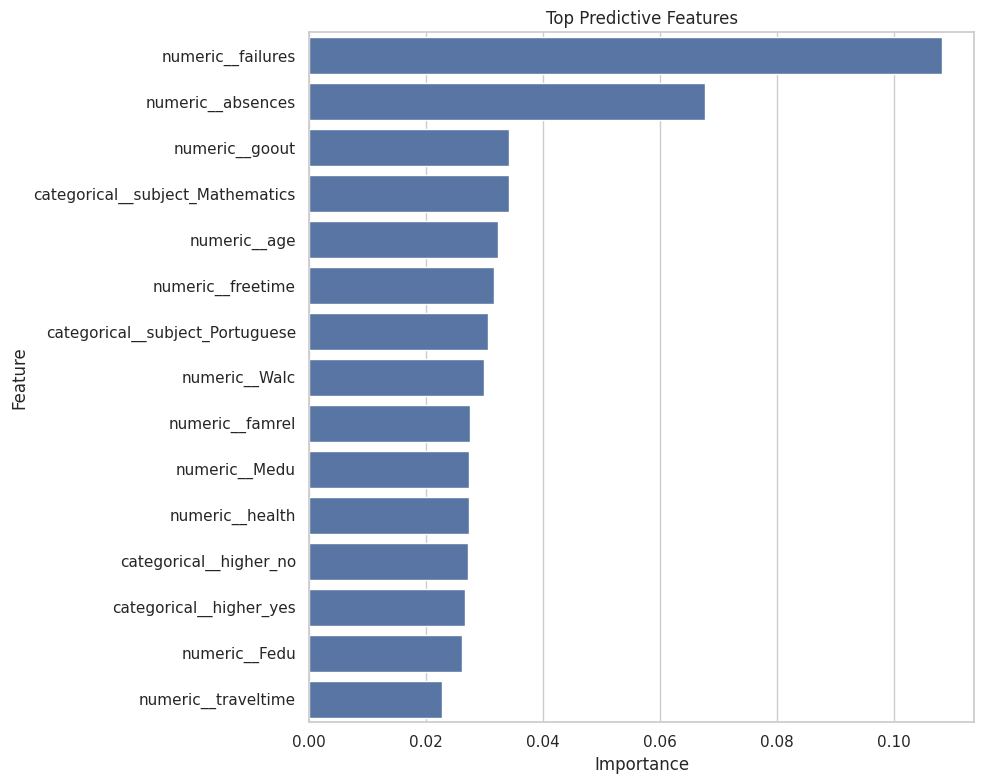

In [23]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Predictive Features"
)

plt.tight_layout()

plt.savefig(
    "week4_feature_importance.png",
    dpi=300
)

plt.show()

In [24]:
insights = pd.DataFrame({

    "Area": [
        "Academic Performance",
        "Study Behaviour",
        "Previous Failures",
        "Attendance",
        "Machine Learning",
        "Feature Analysis"
    ],

    "Analysis": [
        "Final grade distribution was examined.",
        "Study-time categories were compared with final grades.",
        "Previous failures were compared with academic performance.",
        "Absence patterns were examined against final grades.",
        "Multiple classification models were evaluated.",
        "Feature importance was examined using the final Random Forest model."
    ],

    "Potential Implication": [
        "Student performance varies across the dataset.",
        "Study behaviour can be investigated as one performance-related factor.",
        "Previous academic difficulties can be considered when identifying students needing support.",
        "Attendance-related information can be considered alongside other indicators.",
        "Machine learning can provide a supporting prediction mechanism.",
        "Important model features can help guide further investigation."
    ]
})

insights

,Area,Analysis,Potential Implication
0,Academic Performance,Final grade distribution was examined.,Student performance varies across the dataset.
1,Study Behaviour,Study-time categories were compared with final...,Study behaviour can be investigated as one per...
2,Previous Failures,Previous failures were compared with academic ...,Previous academic difficulties can be consider...
3,Attendance,Absence patterns were examined against final g...,Attendance-related information can be consider...
4,Machine Learning,Multiple classification models were evaluated.,Machine learning can provide a supporting pred...
5,Feature Analysis,Feature importance was examined using the fina...,Important model features can help guide furthe...


In [25]:
recommendations = [

    "Use multiple student attributes rather than a single factor when assessing academic risk.",

    "Monitor students who show multiple indicators associated with lower academic performance.",

    "Use attendance and previous academic difficulties as supporting information rather than standalone decision criteria.",

    "Evaluate model performance regularly when new student data becomes available.",

    "Keep teachers and academic staff involved in interpreting model predictions.",

    "Collect additional contextual features in future studies to improve the analysis.",

    "Validate the model on data from other institutions before considering wider deployment."
]

for i, recommendation in enumerate(
    recommendations,
    1
):

    print(
        f"{i}. {recommendation}"
    )

1. Use multiple student attributes rather than a single factor when assessing academic risk.
2. Monitor students who show multiple indicators associated with lower academic performance.
3. Use attendance and previous academic difficulties as supporting information rather than standalone decision criteria.
4. Evaluate model performance regularly when new student data becomes available.
5. Keep teachers and academic staff involved in interpreting model predictions.
6. Collect additional contextual features in future studies to improve the analysis.
7. Validate the model on data from other institutions before considering wider deployment.


In [26]:
limitations = [

    "The dataset represents students from two Portuguese schools and may not generalize to all educational institutions.",

    "The dataset represents a particular collection period and may not reflect current student populations.",

    "The available variables do not capture every factor affecting academic performance.",

    "Machine-learning predictions represent statistical patterns rather than certainty.",

    "The combined Mathematics and Portuguese data require careful interpretation because some students may appear in both subject datasets.",

    "G1 and G2 were excluded from early-risk prediction because their strong relationship with G3 could introduce target leakage."
]

for i, limitation in enumerate(
    limitations,
    1
):

    print(
        f"{i}. {limitation}"
    )

1. The dataset represents students from two Portuguese schools and may not generalize to all educational institutions.
2. The dataset represents a particular collection period and may not reflect current student populations.
3. The available variables do not capture every factor affecting academic performance.
4. Machine-learning predictions represent statistical patterns rather than certainty.
5. The combined Mathematics and Portuguese data require careful interpretation because some students may appear in both subject datasets.
6. G1 and G2 were excluded from early-risk prediction because their strong relationship with G3 could introduce target leakage.


In [27]:
future_work = [

    "Test the model on data from additional schools and regions.",

    "Collect longitudinal student records to study performance over time.",

    "Evaluate additional algorithms and calibrated probability models.",

    "Investigate explainable-AI techniques for individual predictions.",

    "Develop a simple dashboard for teachers or academic advisors.",

    "Monitor model performance after deployment and retrain when necessary."
]

for i, item in enumerate(
    future_work,
    1
):

    print(
        f"{i}. {item}"
    )

1. Test the model on data from additional schools and regions.
2. Collect longitudinal student records to study performance over time.
3. Evaluate additional algorithms and calibrated probability models.
4. Investigate explainable-AI techniques for individual predictions.
5. Develop a simple dashboard for teachers or academic advisors.
6. Monitor model performance after deployment and retrain when necessary.


In [28]:
print("=" * 70)
print("FINAL PRESENTATION STATISTICS")
print("=" * 70)

print("\nDataset:")
print("Records:", len(df))
print("Features:", len(df.columns))

print("\nAcademic:")
print(
    "Average G3:",
    round(df["G3"].mean(), 2)
)

print(
    "Pass rate:",
    round(pass_rate, 2),
    "%"
)

print(
    "Average absences:",
    round(
        df["absences"].mean(),
        2
    )
)

print("\nModel:")
print(
    classification_report(
        y_test,
        predictions
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            (y_test == "Pass").astype(int),
            probabilities
        ),
        4
    )
)

FINAL PRESENTATION STATISTICS

Dataset:
Records: 1044
Features: 35

Academic:
Average G3: 11.34
Pass rate: 77.97 %
Average absences: 4.43

Model:
              precision    recall  f1-score   support

        Fail       0.62      0.22      0.32        46
        Pass       0.81      0.96      0.88       163

    accuracy                           0.80       209
   macro avg       0.72      0.59      0.60       209
weighted avg       0.77      0.80      0.76       209

ROC-AUC: 0.757
